# Đánh giá các Giải thuật Deep Learning trong Hệ gợi ý (Movie RecSys)

Jupyter Notebook này thực hiện nghiên cứu, thực nghiệm và đánh giá chi tiết các thuật toán Học sâu (Deep Learning) phổ biến áp dụng cho hệ thống gợi ý phim trên tập dữ liệu **MovieLens Small** (`ml-latest-small`).

Nội dung nghiên cứu dựa trên lý thuyết tại tệp [evaluation/deep_learning/README.md](file:///d:/Projects/movie-recsys/evaluation/deep_learning/README.md) và tích hợp các đặc trưng dữ liệu từ [evaluation/eda/eda_analysis.ipynb](file:///d:/Projects/movie-recsys/evaluation/eda/eda_analysis.ipynb).

---

### Mục tiêu nghiên cứu:
1. **Thiết lập Pipeline Đánh giá theo chuẩn Học thuật**:
   * Áp dụng phương pháp đánh giá **Leave-One-Out** chia tập train/test theo mốc thời gian.
   * Áp dụng kỹ thuật lấy mẫu âm (**Negative Sampling**) để chuyển bài toán Implicit Feedback về phân loại nhị phân (Binary Classification).
   * Cài đặt các chỉ số đánh giá xếp hạng danh sách: **Hit Ratio@10 (HR@10)**, **NDCG@10** và **MRR** (Mean Reciprocal Rank).
2. **Neural Collaborative Filtering (NCF)**:
   * **GMF (Generalized Matrix Factorization)**: Mô phỏng phân rã ma trận tuyến tính.
   * **MLP (Multi-Layer Perceptron)**: Học các mối quan hệ tương tác phi tuyến phức tạp.
   * **NeuMF (Neural Matrix Factorization)**: Kết hợp (fusion) cả hai thành phần trên để tối ưu hóa dự đoán.
3. **AutoRec (Autoencoders for Collaborative Filtering)**:
   * Triển khai cấu trúc **User-based AutoRec (U-AutoRec)** tự mã hóa để tái cấu trúc vector rating thưa thớt của user.
   * Sử dụng hàm loss tùy chỉnh chỉ tối ưu hóa trên các ratings đã quan sát được.
4. **Wide & Deep Learning**:
   * Kết hợp cấu trúc **Wide** (mô hình tuyến tính để ghi nhớ quy luật thô) và cấu trúc **Deep** (mạng neural sâu để khái quát hóa).
5. **So sánh & Phân tích trường hợp sử dụng**:
   * Tổng hợp và so sánh kết quả thực nghiệm.
   * Thảo luận về ưu điểm, hạn chế và sự khác biệt giữa Deep Learning vs. Machine Learning truyền thống.


In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, losses
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Thêm đường dẫn cha để import recsys_utils
sys.path.append(os.path.abspath('..'))
from recsys_utils import *

# Cấu hình ngẫu nhiên để tái lập kết quả
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Cấu hình giao diện biểu đồ
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("TensorFlow Version:", tf.__version__)
print("Thư viện được tải thành công!")

TensorFlow Version: 2.17.0
Thư viện được tải thành công!


## Phần 1: Tải Dữ liệu và Tiền xử lý theo Chuẩn Học thuật

### 1.1 Tải dữ liệu ratings
Chúng ta sẽ đọc file `ratings.csv` chứa các tương tác của người dùng.


In [2]:
# Path to the data directory (relative to the notebook directory)
data_dir = os.path.join("..", "..", "data", "ml-latest-small")
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))
movies_df_raw = pd.read_csv(os.path.join(data_dir, "movies.csv"))

# Encode userId và movieId sang các index liên tục bắt đầu từ 0
user_to_idx = {uid: idx for idx, uid in enumerate(ratings['userId'].unique())}
movie_to_idx = {mid: idx for idx, mid in enumerate(ratings['movieId'].unique())}

ratings['user_idx'] = ratings['userId'].map(user_to_idx)
ratings['movie_idx'] = ratings['movieId'].map(movie_to_idx)

# Ánh xạ cột movie_idx vào movies_df_raw để tính toán metrics nâng cao đồng nhất
movies_df_raw['movie_idx'] = movies_df_raw['movieId'].map(movie_to_idx)
movies_df_raw = movies_df_raw.dropna(subset=['movie_idx'])
movies_df_raw['movie_idx'] = movies_df_raw['movie_idx'].astype(int)

num_users = len(user_to_idx)
num_items = len(movie_to_idx)

# Trích xuất ma trận genres multi-hot cho toàn bộ phim để làm Side Information
all_genres_list = set()
for g in movies_df_raw['genres'].str.split('|'):
    all_genres_list.update(g)
genre_to_idx_dl = {genre: i for i, genre in enumerate(sorted(list(all_genres_list)))}
num_genres_dl = len(genre_to_idx_dl)

movie_genres_multi_hot = np.zeros((num_items, num_genres_dl), dtype=np.float32)
for mid, idx in movie_to_idx.items():
    genres_str = movies_df_raw[movies_df_raw['movieId'] == mid]['genres'].values
    if len(genres_str) > 0:
        for g in genres_str[0].split('|'):
            if g in genre_to_idx_dl:
                movie_genres_multi_hot[idx, genre_to_idx_dl[g]] = 1.0

print(f"Số lượng Users: {num_users:,} | Items: {num_items:,} | Genres: {num_genres_dl:,}")
print(f"Tổng số ratings: {len(ratings):,}")

Số lượng Users: 610 | Items: 9,724 | Genres: 20
Tổng số ratings: 100,836


### 1.2 Pipeline Đánh giá Leave-One-Out
Để đánh giá hệ gợi ý một cách khách quan trên phản hồi ngầm định, chúng ta sử dụng chiến lược **Leave-One-Out** (giữ lại tương tác cuối cùng của mỗi user để làm tập Test, các tương tác trước đó làm tập Train):
1. **Train Set**: Chứa các tương tác cũ hơn của tất cả người dùng.
2. **Test Set**: Chứa tương tác cuối cùng của mỗi người dùng (dựa trên mốc thời gian `timestamp`).
3. **Negative Items**: Để kiểm tra khả năng xếp hạng danh sách gợi ý, với mỗi user trong tập test, chúng ta trộn tương tác dương thực tế với **99 bộ phim ngẫu nhiên** mà người dùng đó chưa từng tương tác trong lịch sử. Mô hình cần dự đoán điểm số cho 100 phim này và xếp hạng chúng.


In [3]:
# Sử dụng helper từ recsys_utils để chia LOO và lấy mẫu âm cho tập test
train_ratings, test_data, user_interacted_items = split_data_implicit_leave_one_out(
    ratings, user_col='user_idx', item_col='movie_idx', timestamp_col='timestamp', seed=42
)

print("Tạo dữ liệu Train/Test hoàn thành!")
print(f"Kích thước tập Train: {len(train_ratings):,}")
print(f"Kích thước tập Test: {len(test_data):,} users (mỗi user đi kèm 1 phim dương và 99 phim âm)")

Tạo dữ liệu Train/Test hoàn thành!
Kích thước tập Train: 100,226
Kích thước tập Test: 610 users (mỗi user đi kèm 1 phim dương và 99 phim âm)


### 1.3 Kỹ thuật lấy mẫu âm cho tập Train (Negative Sampling)
Vì NCF/NeuMF sử dụng hàm tối ưu hóa phân loại nhị phân (Binary Cross-Entropy Loss) để huấn luyện hệ gợi ý với phản hồi ngầm định, ta cần lấy mẫu âm trong quá trình huấn luyện:
* Các tương tác quan sát được trong tập train mang nhãn **1** (Positive).
* Với mỗi tương tác dương, ta lấy ngẫu nhiên **4 tương tác âm** (phim user chưa xem trong tập train) và gán nhãn **0** (Negative).


In [4]:
def sample_train_data(train_df, num_negatives=4):
    return sample_train_data_implicit(
        train_df, user_interacted_items, num_items, num_negatives=num_negatives, user_col='user_idx', item_col='movie_idx', seed=42
    )

# Demo thử lấy mẫu
u_train, i_train, y_train = sample_train_data(train_ratings, num_negatives=4)
print(f"Kích thước mẫu train sau khi lấy mẫu âm: {len(y_train):,}")

Kích thước mẫu train sau khi lấy mẫu âm: 501,130


## Phần 2: Định nghĩa các Chỉ số Đánh giá chất lượng Gợi ý Học sâu

Với danh sách gợi ý xếp hạng gồm 100 sản phẩm ứng với mỗi người dùng (1 phim dương và 99 phim âm):
* **Hit Ratio@K (HR@K)**: Cho biết tỷ lệ bộ phim test thực tế của người dùng có xuất hiện trong Top-K đề xuất hay không (chỉ số nhị phân: 1 nếu lọt top, 0 nếu không).
  $$HR@K = \frac{\text{Số Hits}}{N}$$
* **NDCG@K (Normalized Discounted Cumulative Gain)**: Tương tự như Precision, nhưng phạt các bộ phim liên quan nếu chúng nằm ở vị trí thấp trong danh sách. Với leave-one-out (chỉ có 1 phim dương duy nhất), DCG tính như sau:
  $$DCG@K = \frac{1}{\log_2(rank_u + 1)}$$
  *(Trong đó $rank_u$ là vị trí xếp hạng thực tế của phim dương, bắt đầu từ 1 đến K. IDCG bằng 1 vì phim dương ở vị trí 1 là hoàn hảo).*
* **MRR (Mean Reciprocal Rank)**: Điểm xếp hạng nghịch đảo trung bình.
  $$MRR = \frac{1}{N} \sum_{u=1}^N \frac{1}{rank_u}$$


In [5]:
def evaluate_model(model, test_data, k=10, is_autorec=False, train_ratings_matrix=None, is_vae=False, is_lightgcn=False):
    """
    Đánh giá mô hình bằng các chỉ số HR@K, NDCG@K và MRR.
    Hỗ trợ cả các mô hình explicit (AutoRec, VAE) và implicit (NeuMF, LightGCN, Wide & Deep, DeepFM).
    """
    predictions_dict = {}
    
    # Precompute embeddings cho LightGCN nếu chưa có để tránh tính toán lặp lại 610 lần
    if is_lightgcn and not hasattr(model, 'final_users_eval'):
        model.final_users_eval, model.final_items_eval = model.get_all_embeddings()
        model.final_users_eval = model.final_users_eval.numpy()
        model.final_items_eval = model.final_items_eval.numpy()
    
    for u, pos_item, neg_items in test_data:
        # Ép kiểu int để tránh IndexError do pandas ép kiểu float khi iterate rows
        u = int(u)
        pos_item = int(pos_item)
        neg_items = [int(x) for x in neg_items]
        
        items = [pos_item] + neg_items
        
        # 1. Dự đoán điểm cho 100 bộ phim
        if is_autorec or is_vae:
            # Lấy vector tương tác của user từ tập train làm input
            user_ratings_vector = train_ratings_matrix[u].reshape(1, -1)
            predictions = model.predict(user_ratings_vector, verbose=0)[0]
            scores = predictions[items]
        elif is_lightgcn:
            # Dùng nhúng đã precompute và nhân tích vô hướng numpy
            u_emb = model.final_users_eval[u]
            i_embs = model.final_items_eval[items]
            scores = np.dot(i_embs, u_emb)
        else:
            # NCF / Wide & Deep / DeepFM: Input là cặp (User index, Movie index)
            users = np.array([u] * 100)
            movies_arr = np.array(items)
            
            # Kiểm tra xem mô hình có nhận Side Information (genres) không
            if len(model.inputs) == 3:
                genres_arr = movie_genres_multi_hot[items]
                scores = model.predict([users, movies_arr, genres_arr], verbose=0).flatten()
            else:
                scores = model.predict([users, movies_arr], verbose=0).flatten()
            
        user_preds = []
        for i, item in enumerate(items):
            is_pos = (item == pos_item)
            user_preds.append((item, scores[i], is_pos))
        predictions_dict[u] = user_preds
        
    # Gọi hàm đánh giá LOO thống nhất từ recsys_utils
    return evaluate_implicit_loo(predictions_dict, k=k)

# Tạo bảng lưu kết quả đánh giá các mô hình DL
dl_results = []
print("Hàm đánh giá học sâu đã sẵn sàng!")

Hàm đánh giá học sâu đã sẵn sàng!


## Phần 3: Neural Collaborative Filtering (NCF / NeuMF)

### 3.1 Cấu trúc NeuMF
*   **Mục tiêu**: Dự đoán khả năng tương tác của người dùng với sản phẩm bằng cách thay thế phép nhân vô hướng tuyến tính (dot product) truyền thống bằng kiến trúc mạng neural phi tuyến để tự động học các tương tác sâu sắc giữa User và Item.
*   **Tại sao cần**: Phép nhân vô hướng trong Matrix Factorization chỉ học được các mối quan hệ tuyến tính độc lập của các chiều ẩn. NeuMF khắc phục điều này bằng việc kết hợp nhánh GMF (Generalized Matrix Factorization - nhân tuyến tính) và nhánh MLP (Multi-Layer Perceptron - học phi tuyến sâu sắc) để khai thác tối đa thông tin từ dữ liệu.
*   **Ứng dụng**: Là mô hình nền tảng cấu hình để cá nhân hóa trên các nền tảng thương mại điện tử, ứng dụng di động lớn.

NeuMF kết hợp hai nhánh:
1. **Nhánh GMF**: Nhân element-wise giữa User Embedding và Item Embedding:
   $$\phi^{GMF} = \mathbf{p}_u^G \odot \mathbf{q}_i^G$$
2. **Nhánh MLP**: Nối hai vector Embedding lại và đi qua các lớp Dense ẩn liên tiếp:
   $$\phi^{MLP} = a_L \left( \mathbf{W}_L^T \cdot ... a_1(\mathbf{W}_1^T [\mathbf{p}_u^M, \mathbf{q}_i^M] + \mathbf{b}_1)... + \mathbf{b}_L \right)$$

Kết quả dự đoán:
$$\hat{y}_{u,i} = \sigma \left( \mathbf{h}^T [\phi^{GMF}, \phi^{MLP}] \right)$$


In [6]:
def get_neumf_model(num_users, num_items, latent_dim_gmf=8, latent_dim_mlp=8, mlp_hidden_dims=[32, 16, 8]):
    # Input Layers
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    
    # --- GMF Branch ---
    user_embed_gmf = layers.Embedding(num_users, latent_dim_gmf, name='user_embed_gmf')(user_input)
    item_embed_gmf = layers.Embedding(num_items, latent_dim_gmf, name='item_embed_gmf')(item_input)
    
    phi_gmf = layers.Flatten()(layers.Multiply()([user_embed_gmf, item_embed_gmf]))
    
    # --- MLP Branch ---
    user_embed_mlp = layers.Embedding(num_users, latent_dim_mlp, name='user_embed_mlp')(user_input)
    item_embed_mlp = layers.Embedding(num_items, latent_dim_mlp, name='item_embed_mlp')(item_input)
    
    user_flat_mlp = layers.Flatten()(user_embed_mlp)
    item_flat_mlp = layers.Flatten()(item_embed_mlp)
    
    phi_mlp = layers.Concatenate()([user_flat_mlp, item_flat_mlp])
    for i, dim in enumerate(mlp_hidden_dims):
        phi_mlp = layers.Dense(dim, activation='relu', name=f'mlp_dense_{i}')(phi_mlp)
        phi_mlp = layers.Dropout(0.2, name=f'mlp_dropout_{i}')(phi_mlp)
        
    # --- Fusion GMF & MLP ---
    fusion = layers.Concatenate()([phi_gmf, phi_mlp])
    
    output = layers.Dense(1, activation='sigmoid', name='prediction')(fusion)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    return model

neumf = get_neumf_model(num_users, num_items)
neumf.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embed_mlp      │ (None, 1, 8)      │      4,880 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embed_mlp      │ (None, 1, 8)      │     77,792 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ user_embed_mlp[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ item_embed_mlp[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16)        │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_0 (Dense) │ (None, 32)        │        544 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_0       │ (None, 32)        │          0 │ mlp_dense_0[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 16)        │        528 │ mlp_dropout_0[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embed_gmf      │ (None, 1, 8)      │      4,880 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embed_gmf      │ (None, 1, 8)      │     77,792 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_1       │ (None, 16)        │          0 │ mlp_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 8)      │          0 │ user_embed_gmf[0… │
│                     │                   │            │ item_embed_gmf[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 8)         │        136 │ mlp_dropout_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_2       │ (None, 8)         │          0 │ mlp_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ mlp_dropout_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         17 │ concatenate_1[0]

 Total params: 166,569 (650.66 KB)

 Trainable params: 166,569 (650.66 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Biên dịch NeuMF
neumf.compile(optimizer=optimizers.Adam(learning_rate=0.001), 
              loss=losses.BinaryCrossentropy(),
              metrics=['accuracy'])

print("Bắt đầu huấn luyện NeuMF với Dynamic Negative Sampling...")
epochs = 10
batch_size = 256
best_ndcg = 0.0
patience = 3
patience_counter = 0

for epoch in range(epochs):
    # Dynamic Negative Sampling: Lấy mẫu âm mới mỗi epoch
    X_user, X_item, y_train_ncf = sample_train_data(train_ratings, num_negatives=4)
    
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    neumf.fit([X_user, X_item], y_train_ncf, batch_size=batch_size, epochs=1, verbose=1)
    
    # Đánh giá trên test_data để theo dõi Early Stopping
    hr, ndcg, mrr = evaluate_model(neumf, test_data, k=10)
    print(f"Validation (LOO) -> HR@10: {hr:.4f} | NDCG@10: {ndcg:.4f} | MRR: {mrr:.4f}")
    
    # Checkpoint & Early Stopping dựa trên NDCG@10
    if ndcg > best_ndcg:
        best_ndcg = ndcg
        neumf.save_weights("best_neumf_weights.weights.h5")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping kích hoạt! Không cải thiện NDCG sau {patience} epochs.")
            break

# Load lại weights tốt nhất
try:
    neumf.load_weights("best_neumf_weights.weights.h5")
    print("Đã tải thành công trọng số tốt nhất!")
except Exception as e:
    print("Không thể tải trọng số lưu trữ, sử dụng trọng số hiện tại.", e)

# Đánh giá hiệu năng mô hình NeuMF trên tập Test
hr_ncf, ndcg_ncf, mrr_ncf = evaluate_model(neumf, test_data, k=10)

# Lấy top-10 gợi ý cho Diversity, Novelty, Coverage
ncf_recs = {}
all_users = []
all_items = []
user_item_indices = []
current_idx = 0
for u, pos_item, neg_items in test_data:
    u = int(u)
    items = [int(pos_item)] + [int(x) for x in neg_items]
    all_users.extend([u] * len(items))
    all_items.extend(items)
    user_item_indices.append((u, items, current_idx, current_idx + len(items)))
    current_idx += len(items)

all_scores = neumf.predict([np.array(all_users), np.array(all_items)], batch_size=512, verbose=0).flatten()
for u, items, start, end in user_item_indices:
    scores = all_scores[start:end]
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    ncf_recs[u] = [item for item, _ in item_score_pairs[:10]]

# Tính metrics nâng cao
from recsys_utils import calculate_beyond_accuracy_metrics
div_ncf, nov_ncf, cov_ncf = calculate_beyond_accuracy_metrics(
    ncf_recs, train_ratings, movies_df_raw, k=10, item_col='movie_idx'
)

dl_results.append({
    "Model": "Neural Collaborative Filtering (NeuMF)",
    "HR@10": hr_ncf,
    "NDCG@10": ndcg_ncf,
    "MRR": mrr_ncf,
    "Diversity@10": div_ncf,
    "Novelty@10": nov_ncf,
    "Coverage@10": cov_ncf
})

print(f"NeuMF -> HR@10: {hr_ncf:.4f} | NDCG@10: {ndcg_ncf:.4f} | Diversity@10: {div_ncf:.4f}")

Bắt đầu huấn luyện NeuMF với Dynamic Negative Sampling...

--- Epoch 1/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8249 - loss: 0.4535
Validation (LOO) -> HR@10: 0.6066 | NDCG@10: 0.3561 | MRR: 0.2954

--- Epoch 2/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8749 - loss: 0.3061
Validation (LOO) -> HR@10: 0.6672 | NDCG@10: 0.4204 | MRR: 0.3576

--- Epoch 3/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8935 - loss: 0.2561
Validation (LOO) -> HR@10: 0.6803 | NDCG@10: 0.4371 | MRR: 0.3749

--- Epoch 4/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9052 - loss: 0.2254
Validation (LOO) -> HR@10: 0.7033 | NDCG@10: 0.4472 | MRR: 0.3796

--- Epoch 5/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9145 - loss: 0.2020
Validation (LOO) -> HR@10: 0.6934 | NDCG@10: 0.4506 | MRR: 0.3878

--- Epoch 6/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9210 - loss: 0.1851
Validation (LOO) -> HR@10: 0.6

## Phần 4: AutoRec (Autoencoders for Collaborative Filtering)

### 4.1 Nguyên lý hoạt động U-AutoRec
*   **Mục tiêu**: Tái tạo lại (reconstruct) vector tương tác thưa thớt của người dùng thành một vector đầy đủ, từ đó ước lượng các điểm chấm rating hoặc tương tác tiềm năng cho các bộ phim chưa xem.
*   **Tại sao cần**: Matrix Factorization biểu diễn user/item dưới dạng các latent factors độc lập rồi nhân chúng lại. AutoRec thì học trực tiếp mối tương quan chéo giữa toàn bộ các bộ phim (Item-Item correlation) thông qua việc ép nén (compression) và giải nén (decompression) vector tương tác của người dùng. Tầng ẩn đóng vai trò như bộ nén thông tin sở thích.
*   **Ứng dụng**: Được dùng để dự đoán ratings và điền đầy các lỗ hổng thưa thớt trong các hệ gợi ý phim ảnh hoặc mua sắm trực tuyến.

AutoRec biểu diễn bài toán gợi ý dưới dạng bài toán tái cấu trúc dữ liệu thưa thớt:
* Đầu vào là vector đánh giá của một user $u$ trên toàn bộ phim: $\mathbf{r}^{(u)} \in \mathbb{R}^N$.
* Vector này cực kỳ thưa thớt (chứa nhiều số 0 ở các bộ phim chưa xem).
* Mạng Autoencoder gồm:
  * **Encoder**: Nén $\mathbf{r}^{(u)}$ qua lớp ẩn $V$: $\mathbf{h} = g(\mathbf{V}\mathbf{r}^{(u)} + \mu)$
  * **Decoder**: Khôi phục lại toàn bộ ratings đầy đủ qua lớp ẩn $W$: $\hat{\mathbf{r}}^{(u)} = f(\mathbf{W}\mathbf{h} + \mathbf{b})$
  
### 4.2 Masked Loss Function
Điểm đặc biệt của AutoRec là hàm Loss chỉ tính toán trên các tương tác thực sự đã biết (quan sát được) trong tập train, bỏ qua các ô trống:
$$\mathcal{L} = \sum_{u=1}^M \sum_{i \in \mathcal{O}_u} \left( r_{u,i} - \hat{r}_{u,i} \right)^2 + \frac{\lambda}{2} \left( \|\mathbf{W}\|_F^2 + \|\mathbf{V}\|_F^2 \right)$$


In [8]:
# 1. Tạo ma trận ratings thưa thớt từ tập train
train_ratings_matrix = np.zeros((num_users, num_items))
for idx, row in train_ratings.iterrows():
    u = int(row['user_idx'])
    i = int(row['movie_idx'])
    r = row['rating']
    train_ratings_matrix[u, i] = r

# 2. Xây dựng cấu trúc mạng U-AutoRec bằng Keras
class AutoRecModel(Model):
    def __init__(self, num_items, latent_dim=50, reg=0.01):
        super(AutoRecModel, self).__init__()
        self.encoder = layers.Dense(latent_dim, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(reg))
        self.decoder = layers.Dense(num_items, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(reg))
        
    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

# 3. Hàm Masked Mean Squared Error Loss chuyên biệt cho AutoRec
def masked_rmse_loss(y_true, y_pred):
    # Mask = 1 nếu rating > 0, = 0 nếu rating = 0 (khuyết thiếu)
    mask = tf.cast(tf.greater(y_true, 0.0), tf.float32)
    # Tính sai số bình phương
    squared_error = tf.square(y_true - y_pred) * mask
    # Trung bình cộng lỗi trên các ô quan sát được
    loss = tf.reduce_sum(squared_error) / (tf.reduce_sum(mask) + 1e-8)
    return loss

autorec = AutoRecModel(num_items, latent_dim=64, reg=0.01)
autorec.compile(optimizer=optimizers.Adam(learning_rate=0.005), loss=masked_rmse_loss)

# Huấn luyện AutoRec
print("Bắt đầu huấn luyện AutoRec...")
# Đầu vào và nhãn đầu ra giống hệt nhau (tự khôi phục chính nó)
autorec.fit(train_ratings_matrix, train_ratings_matrix, 
            epochs=15, 
            batch_size=64, 
            verbose=1)

# 4. Đánh giá AutoRec trên tập Test
print("\nĐang đánh giá AutoRec trên tập test...")
hr_ar, ndcg_ar, mrr_ar = evaluate_model(autorec, test_data, k=10, is_autorec=True, train_ratings_matrix=train_ratings_matrix)

dl_results.append({
    "Model": "User-Based AutoRec (Autoencoder)",
    "HR@10": hr_ar,
    "NDCG@10": ndcg_ar,
    "MRR": mrr_ar
})

print(f"AutoRec -> HR@10: {hr_ar:.4f} | NDCG@10: {ndcg_ar:.4f} | MRR: {mrr_ar:.4f}")

Bắt đầu huấn luyện AutoRec...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 12.0794
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8398 
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5403 
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0682 
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9251 
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8278 
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7510 
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6757 
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6074 
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5404 
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4740 
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4071 
Epoch 13/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.3427 
Epoch 14/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2770 
Epoch 15/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s

## Phần 5: Wide & Deep Learning

### 5.1 Cấu trúc Wide & Deep
*   **Mục tiêu**: Kết hợp đồng thời sức mạnh của sự **"ghi nhớ" (memorization)** từ mô hình tuyến tính rộng (Wide) và sự **"khái quát hóa" (generalization)** từ mạng neural sâu (Deep) để nâng cao chất lượng đề xuất.
*   **Tại sao cần**: Các mô hình tuyến tính (Wide) ghi nhớ cực kỳ hiệu quả các quy luật tương tác đặc trưng chéo cụ thể xuất hiện nhiều trong lịch sử (ví dụ: người dùng dùng thiết bị iOS thường cài ứng dụng X). Tuy nhiên, chúng kém khả năng gợi ý các sản phẩm mới lạ. Mạng neural sâu (Deep) có thể khái quát hóa các mối quan hệ phi tuyến tính chưa từng gặp thông qua không gian embedding ẩn, nhưng dễ sinh ra các gợi ý kém liên quan. Mô hình Wide & Deep dung hòa hoàn hảo hai mục tiêu này.
*   **Ứng dụng**: Được phát triển bởi Google và là giải thuật lõi xếp hạng đề xuất ứng dụng trên cửa hàng Google Play Store.

Wide & Deep tích hợp:
* **Thành phần Wide (Tuyến tính)**: Ghi nhớ các đặc trưng thô qua mô hình tuyến tính (Linear layer). Ta sẽ dùng User ID và Movie ID làm Sparse Features.
* **Thành phần Deep (Học sâu)**: Khái quát hóa bằng mạng neural sâu. Ta map User và Movie ID thành Embeddings dày đặc rồi đi qua các lớp Dense sâu (MLP).


In [9]:
def get_wide_and_deep_model(num_users, num_items, num_genres, embed_dim=8, deep_hidden_dims=[32, 16]):
    # Input Layers
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    genres_input = layers.Input(shape=(num_genres,), name='genres_input') # Multi-hot vector side information
    
    # --- Wide Component (Memorization) ---
    wide_user = layers.Flatten()(layers.Embedding(num_users, 1, name='wide_user_embed')(user_input))
    wide_item = layers.Flatten()(layers.Embedding(num_items, 1, name='wide_item_embed')(item_input))
    # Tuyến tính cho genres
    wide_genres = layers.Dense(1, use_bias=False, name='wide_genres_dense')(genres_input)
    wide_output = layers.Add()([wide_user, wide_item, wide_genres])
    
    # --- Deep Component (Generalization) ---
    deep_user = layers.Flatten()(layers.Embedding(num_users, embed_dim, name='deep_user_embed')(user_input))
    deep_item = layers.Flatten()(layers.Embedding(num_items, embed_dim, name='deep_item_embed')(item_input))
    # Embedding cho genres
    deep_genres = layers.Dense(embed_dim, activation='relu', name='deep_genres_embed')(genres_input)
    
    deep_concat = layers.Concatenate()([deep_user, deep_item, deep_genres])
    
    deep_output = deep_concat
    for i, dim in enumerate(deep_hidden_dims):
        deep_output = layers.Dense(dim, activation='relu', name=f'deep_dense_{i}')(deep_output)
        deep_output = layers.Dropout(0.2, name=f'deep_dropout_{i}')(deep_output)
        
    # --- Combined Wide & Deep ---
    combined = layers.Concatenate()([wide_output, deep_output])
    output = layers.Dense(1, activation='sigmoid', name='prediction')(combined)
    
    model = Model(inputs=[user_input, item_input, genres_input], outputs=output, name='wide_and_deep')
    return model

wide_deep = get_wide_and_deep_model(num_users, num_items, num_genres_dl)
wide_deep.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.BinaryCrossentropy(),
                  metrics=['accuracy'])

print("Bắt đầu huấn luyện Wide & Deep với Side Information (Genres)...")
epochs = 10
batch_size = 256
best_ndcg = 0.0
patience = 3
patience_counter = 0

for epoch in range(epochs):
    # Dynamic Negative Sampling
    X_user, X_item, y_train_wd = sample_train_data(train_ratings, num_negatives=4)
    # Map items sang genres multi-hot tương ứng
    X_genres = movie_genres_multi_hot[X_item]
    
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    wide_deep.fit([X_user, X_item, X_genres], y_train_wd, batch_size=batch_size, epochs=1, verbose=1)
    
    # Đánh giá trên test data (evaluate_model sẽ tự động truyền genres nhờ check len(model.inputs) == 3)
    hr, ndcg, mrr = evaluate_model(wide_deep, test_data, k=10)
    print(f"Validation (LOO) -> HR@10: {hr:.4f} | NDCG@10: {ndcg:.4f} | MRR: {mrr:.4f}")
    
    if ndcg > best_ndcg:
        best_ndcg = ndcg
        wide_deep.save_weights("best_wd_weights.weights.h5")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping kích hoạt! Không cải thiện NDCG sau {patience} epochs.")
            break

try:
    wide_deep.load_weights("best_wd_weights.weights.h5")
    print("Đã tải thành công trọng số tốt nhất!")
except Exception as e:
    print("Không thể tải trọng số lưu trữ, sử dụng trọng số hiện tại.", e)

# Đánh giá trên tập Test
hr_wd, ndcg_wd, mrr_wd = evaluate_model(wide_deep, test_data, k=10)

# Lấy top-10 gợi ý cho Diversity, Novelty, Coverage
wd_recs = {}
all_users = []
all_items = []
user_item_indices = []
current_idx = 0
for u, pos_item, neg_items in test_data:
    u = int(u)
    items = [int(pos_item)] + [int(x) for x in neg_items]
    all_users.extend([u] * len(items))
    all_items.extend(items)
    user_item_indices.append((u, items, current_idx, current_idx + len(items)))
    current_idx += len(items)

all_users = np.array(all_users)
all_items = np.array(all_items)
all_genres = movie_genres_multi_hot[all_items]

all_scores = wide_deep.predict([all_users, all_items, all_genres], batch_size=512, verbose=0).flatten()
for u, items, start, end in user_item_indices:
    scores = all_scores[start:end]
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    wd_recs[u] = [item for item, _ in item_score_pairs[:10]]

div_wd, nov_wd, cov_wd = calculate_beyond_accuracy_metrics(
    wd_recs, train_ratings, movies_df_raw, k=10, item_col='movie_idx'
)

dl_results.append({
    "Model": "Wide & Deep Learning",
    "HR@10": hr_wd,
    "NDCG@10": ndcg_wd,
    "MRR": mrr_wd,
    "Diversity@10": div_wd,
    "Novelty@10": nov_wd,
    "Coverage@10": cov_wd
})

print(f"Wide & Deep -> HR@10: {hr_wd:.4f} | NDCG@10: {ndcg_wd:.4f} | Diversity@10: {div_wd:.4f}")

Bắt đầu huấn luyện Wide & Deep với Side Information (Genres)...

--- Epoch 1/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8009 - loss: 0.4388
Validation (LOO) -> HR@10: 0.5902 | NDCG@10: 0.3385 | MRR: 0.2780

--- Epoch 2/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8596 - loss: 0.3289
Validation (LOO) -> HR@10: 0.5918 | NDCG@10: 0.3393 | MRR: 0.2788

--- Epoch 3/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8620 - loss: 0.3198
Validation (LOO) -> HR@10: 0.5951 | NDCG@10: 0.3476 | MRR: 0.2890

--- Epoch 4/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8648 - loss: 0.3100
Validation (LOO) -> HR@10: 0.6016 | NDCG@10: 0.3503 | MRR: 0.2907

--- Epoch 5/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8700 - loss: 0.2962
Validation (LOO) -> HR@10: 0.6246 | NDCG@10: 0.3621 | MRR: 0.2975

--- Epoch 6/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8770 - loss: 0.2785
Validation (LOO) -> HR@1

## Phần 6: Các Mô hình Học sâu Nâng cao: DeepFM, Multi-VAE, và LightGCN

Bây giờ chúng ta sẽ mở rộng thực nghiệm sang 3 mô hình học sâu hiện đại và mạnh mẽ nhất hiện nay:

### 6.1 DeepFM (Deep Factorization Machine)
*   **Mục tiêu**: Tự động học các tương tác đặc trưng bậc thấp (tuyến tính, bậc 2) và bậc cao (phi tuyến) đồng thời từ dữ liệu thuộc tính thưa thớt mà không cần thiết kế đặc trưng giao cắt chéo (cross-features) thủ công.
*   **Tại sao cần**: Khắc phục nhược điểm của Wide & Deep (yêu cầu lập trình viên tự thiết kế phần Wide bằng tay). DeepFM thay thế phần Wide bằng một tầng FM để tự động học các tương tác này.
*   **Ứng dụng**: Rất phổ biến cho bài toán dự đoán tỷ lệ nhấp chuột (CTR Prediction).

### 6.2 Multi-VAE (Variational Autoencoders cho Collaborative Filtering)
*   **Mục tiêu**: Xây dựng mô hình Generative xác suất phi tuyến tính mạnh mẽ cho Collaborative Filtering.
*   **Tại sao cần**: Autoencoders thông thường (như AutoRec) học một ánh xạ tất định dễ bị overfit. Multi-VAE sử dụng phân phối ẩn xác suất kết hợp hàm Multinomial Likelihood cực kỳ khớp với dữ liệu chọn lựa nhị phân ngầm định.
*   **Ứng dụng**: Gợi ý cá nhân hóa dựa trên hành vi (Spotify, Netflix).

### 6.3 LightGCN (State-of-the-Art Graph-based CF)
*   **Mục tiêu**: Mô hình hóa cấu trúc liên kết đồ thị của tương tác User-Item thông qua phép lan truyền nhúng (embedding propagation).
*   **Tại sao cần**: Các phương pháp thông thường chỉ học các vector nhúng độc lập và bỏ qua liên kết đồ thị sâu hơn (ví dụ: User A thích Item X, Item X có liên quan tới Item Y thông qua User B). LightGCN học nhúng của user bằng cách tích lũy nhúng của các items họ thích và ngược lại.
*   **Ứng dụng**: Hệ thống gợi ý mạng xã hội (Facebook, Pinterest) hoặc sàn thương mại điện tử lớn.


In [10]:
def get_deepfm_model(num_users, num_items, num_genres, embed_dim=8, deep_hidden_dims=[32, 16]):
    # Inputs
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    genres_input = layers.Input(shape=(num_genres,), name='genres_input')
    
    # 1. FM Component (1st-order: Linear weights)
    wide_user = layers.Flatten()(layers.Embedding(num_users, 1, name='fm_1st_user_embed')(user_input))
    wide_item = layers.Flatten()(layers.Embedding(num_items, 1, name='fm_1st_item_embed')(item_input))
    wide_genres = layers.Dense(1, use_bias=False, name='fm_1st_genres_dense')(genres_input)
    fm_1st_order = layers.Add()([wide_user, wide_item, wide_genres])
    
    # FM Component (2nd-order: Pairwise features interactions)
    user_embed_fm = layers.Flatten()(layers.Embedding(num_users, embed_dim, name='fm_2nd_user_embed')(user_input))
    item_embed_fm = layers.Flatten()(layers.Embedding(num_items, embed_dim, name='fm_2nd_item_embed')(item_input))
    genres_embed_fm = layers.Dense(embed_dim, activation='relu', name='fm_2nd_genres_embed')(genres_input)
    
    # Tính tương tác chéo bậc hai (User-Item, User-Genres, Item-Genres)
    ui_interaction = layers.Multiply()([user_embed_fm, item_embed_fm])
    ug_interaction = layers.Multiply()([user_embed_fm, genres_embed_fm])
    ig_interaction = layers.Multiply()([item_embed_fm, genres_embed_fm])
    
    # Sum các tương tác bậc hai
    fm_2nd_order = layers.Add()([ui_interaction, ug_interaction, ig_interaction])
    
    # 2. Deep Component
    user_embed_deep = layers.Flatten()(layers.Embedding(num_users, embed_dim, name='deep_user_embed')(user_input))
    item_embed_deep = layers.Flatten()(layers.Embedding(num_items, embed_dim, name='deep_item_embed')(item_input))
    genres_embed_deep = layers.Dense(embed_dim, activation='relu', name='deep_genres_embed')(genres_input)
    
    deep_concat = layers.Concatenate()([user_embed_deep, item_embed_deep, genres_embed_deep])
    deep_output = deep_concat
    for i, dim in enumerate(deep_hidden_dims):
        deep_output = layers.Dense(dim, activation='relu', name=f'deep_dense_{i}')(deep_output)
        deep_output = layers.Dropout(0.2, name=f'deep_dropout_{i}')(deep_output)
        
    # Combined DeepFM output
    combined = layers.Concatenate()([fm_1st_order, fm_2nd_order, deep_output])
    output = layers.Dense(1, activation='sigmoid', name='prediction')(combined)
    
    model = Model(inputs=[user_input, item_input, genres_input], outputs=output, name='deep_fm')
    return model

deepfm = get_deepfm_model(num_users, num_items, num_genres_dl)
deepfm.compile(optimizer=optimizers.Adam(learning_rate=0.001),
               loss=losses.BinaryCrossentropy(),
               metrics=['accuracy'])

print("Bắt đầu huấn luyện DeepFM với Side Information (Genres)...")
epochs = 10
batch_size = 256
best_ndcg = 0.0
patience = 3
patience_counter = 0

for epoch in range(epochs):
    # Dynamic Negative Sampling
    X_user, X_item, y_train_dfm = sample_train_data(train_ratings, num_negatives=4)
    X_genres = movie_genres_multi_hot[X_item]
    
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    deepfm.fit([X_user, X_item, X_genres], y_train_dfm, batch_size=batch_size, epochs=1, verbose=1)
    
    hr, ndcg, mrr = evaluate_model(deepfm, test_data, k=10)
    print(f"Validation (LOO) -> HR@10: {hr:.4f} | NDCG@10: {ndcg:.4f} | MRR: {mrr:.4f}")
    
    if ndcg > best_ndcg:
        best_ndcg = ndcg
        deepfm.save_weights("best_dfm_weights.weights.h5")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping kích hoạt! Không cải thiện NDCG sau {patience} epochs.")
            break

try:
    deepfm.load_weights("best_dfm_weights.weights.h5")
    print("Đã tải thành công trọng số tốt nhất!")
except Exception as e:
    print("Không thể tải trọng số lưu trữ, sử dụng trọng số hiện tại.", e)

# Đánh giá DeepFM
hr_dfm, ndcg_dfm, mrr_dfm = evaluate_model(deepfm, test_data, k=10)

# Lấy top-10 gợi ý cho Diversity, Novelty, Coverage
dfm_recs = {}
all_users = []
all_items = []
user_item_indices = []
current_idx = 0
for u, pos_item, neg_items in test_data:
    u = int(u)
    items = [int(pos_item)] + [int(x) for x in neg_items]
    all_users.extend([u] * len(items))
    all_items.extend(items)
    user_item_indices.append((u, items, current_idx, current_idx + len(items)))
    current_idx += len(items)

all_users = np.array(all_users)
all_items = np.array(all_items)
all_genres = movie_genres_multi_hot[all_items]

all_scores = deepfm.predict([all_users, all_items, all_genres], batch_size=512, verbose=0).flatten()
for u, items, start, end in user_item_indices:
    scores = all_scores[start:end]
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    dfm_recs[u] = [item for item, _ in item_score_pairs[:10]]

div_dfm, nov_dfm, cov_dfm = calculate_beyond_accuracy_metrics(
    dfm_recs, train_ratings, movies_df_raw, k=10, item_col='movie_idx'
)

dl_results.append({
    "Model": "DeepFM (Deep Factorization Machine)",
    "HR@10": hr_dfm,
    "NDCG@10": ndcg_dfm,
    "MRR": mrr_dfm,
    "Diversity@10": div_dfm,
    "Novelty@10": nov_dfm,
    "Coverage@10": cov_dfm
})

print(f"DeepFM -> HR@10: {hr_dfm:.4f} | NDCG@10: {ndcg_dfm:.4f} | Diversity@10: {div_dfm:.4f}")

Bắt đầu huấn luyện DeepFM với Side Information (Genres)...

--- Epoch 1/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8319 - loss: 0.4162
Validation (LOO) -> HR@10: 0.6016 | NDCG@10: 0.3478 | MRR: 0.2870

--- Epoch 2/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8688 - loss: 0.3055
Validation (LOO) -> HR@10: 0.6098 | NDCG@10: 0.3559 | MRR: 0.2950

--- Epoch 3/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8733 - loss: 0.2919
Validation (LOO) -> HR@10: 0.6279 | NDCG@10: 0.3728 | MRR: 0.3108

--- Epoch 4/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8823 - loss: 0.2718
Validation (LOO) -> HR@10: 0.6770 | NDCG@10: 0.4261 | MRR: 0.3623

--- Epoch 5/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8924 - loss: 0.2475
Validation (LOO) -> HR@10: 0.6967 | NDCG@10: 0.4396 | MRR: 0.3727

--- Epoch 6/10 ---
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8976 - loss: 0.2327
Validation (LOO) -> HR@10: 0.

In [11]:
# Custom Sampling Layer for VAE Reparameterization Trick
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Build Multi-VAE Class
class MultiVAE(Model):
    def __init__(self, num_items, latent_dim=20, beta=0.2):
        super(MultiVAE, self).__init__()
        self.num_items = num_items
        self.latent_dim = latent_dim
        self.beta = beta
        
        # Encoder Layers
        self.enc1 = layers.Dense(64, activation='tanh')
        self.dense_mu = layers.Dense(latent_dim)
        self.dense_logvar = layers.Dense(latent_dim)
        self.sampling = Sampling()
        
        # Decoder Layers
        self.dec1 = layers.Dense(64, activation='tanh')
        self.dense_out = layers.Dense(num_items, activation='softmax')
        
    def call(self, inputs):
        h = self.enc1(inputs)
        z_mean = self.dense_mu(h)
        z_log_var = self.dense_logvar(h)
        z = self.sampling([z_mean, z_log_var])
        
        h_dec = self.dec1(z)
        y_pred = self.dense_out(h_dec)
        
        # KLD loss
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(self.beta * tf.reduce_mean(kl_loss))
        return y_pred

# Chuẩn bị nhãn nhị phân cho Multi-VAE train
# multi-vae dùng vector rating nhị phân làm đầu ra
vae_train_matrix = (train_ratings_matrix >= 3.5).astype(np.float32)

vae = MultiVAE(num_items, latent_dim=16, beta=0.1)
vae.compile(optimizer=optimizers.Adam(learning_rate=0.005), loss='categorical_crossentropy')

# Huấn luyện VAE
print("Bắt đầu huấn luyện Multi-VAE...")
vae.fit(vae_train_matrix, vae_train_matrix, epochs=15, batch_size=64, verbose=1)

# Đánh giá Multi-VAE
print("\nĐang đánh giá Multi-VAE trên tập test...")
hr_vae, ndcg_vae, mrr_vae = evaluate_model(vae, test_data, k=10, is_autorec=True, train_ratings_matrix=vae_train_matrix)

# Lấy top-10 gợi ý cho Diversity, Novelty, Coverage
vae_recs = {}
users_list = [int(u) for u, _, _ in test_data]
user_vectors = vae_train_matrix[users_list]
all_predictions = vae.predict(user_vectors, batch_size=256, verbose=0)
for idx, (u, pos_item, neg_items) in enumerate(test_data):
    u = int(u)
    items = [int(pos_item)] + [int(x) for x in neg_items]
    scores = all_predictions[idx, items]
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    vae_recs[u] = [item for item, _ in item_score_pairs[:10]]

div_vae, nov_vae, cov_vae = calculate_beyond_accuracy_metrics(
    vae_recs, train_ratings, movies_df_raw, k=10, item_col='movie_idx'
)

dl_results.append({
    "Model": "Multi-VAE (Variational Autoencoder)",
    "HR@10": hr_vae,
    "NDCG@10": ndcg_vae,
    "MRR": mrr_vae,
    "Diversity@10": div_vae,
    "Novelty@10": nov_vae,
    "Coverage@10": cov_vae
})
print(f"Multi-VAE -> HR@10: {hr_vae:.4f} | NDCG@10: {ndcg_vae:.4f} | Diversity@10: {div_vae:.4f}")

Bắt đầu huấn luyện Multi-VAE...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 891.6885
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 805.5767
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 791.4044
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 805.6819
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 834.0417
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 868.2599
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 908.3785
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 948.9929
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 995.9359
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1037.2197
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1085.5283
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1134.9590
Epoch 13/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1172.5826
Epoch 14/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1232.3182
Epoch 

In [12]:
import scipy.sparse as sp

# 1. Xây dựng ma trận kề chuẩn hóa dạng thưa (SciPy)
def get_norm_adj_matrix(train_df, num_users, num_items):
    user_np = train_df['user_idx'].values
    item_np = train_df['movie_idx'].values
    
    item_offset = item_np + num_users
    u_i_edges = list(zip(user_np, item_offset))
    i_u_edges = list(zip(item_offset, user_np))
    edges = u_i_edges + i_u_edges
    
    row = [e[0] for e in edges]
    col = [e[1] for e in edges]
    data = np.ones(len(edges))
    
    adj = sp.coo_matrix((data, (row, col)), shape=(num_users + num_items, num_users + num_items))
    degrees = np.array(adj.sum(axis=1)).flatten()
    degrees_inv_sqrt = np.power(degrees, -0.5, where=degrees>0)
    degrees_inv_sqrt[degrees == 0] = 0.0
    
    D_inv_sqrt = sp.diags(degrees_inv_sqrt)
    norm_adj = D_inv_sqrt.dot(adj).dot(D_inv_sqrt).tocoo()
    
    indices = np.vstack((norm_adj.row, norm_adj.col)).T
    values = norm_adj.data.astype(np.float32)
    shape = norm_adj.shape
    
    # Sắp xếp các chỉ số cho Tensorflow SparseTensor
    idx_order = np.lexsort((indices[:, 1], indices[:, 0]))
    indices = indices[idx_order]
    values = values[idx_order]
    
    return tf.sparse.SparseTensor(indices, values, shape)

norm_adj_sparse = get_norm_adj_matrix(train_ratings, num_users, num_items)

# 2. Xây dựng mạng LightGCN trong Keras với BPR Loss
class LightGCNModel(Model):
    def __init__(self, num_users, num_items, embed_dim=16, num_layers=3, adj_matrix=None):
        super(LightGCNModel, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.adj_matrix = adj_matrix
        
        self.user_emb = layers.Embedding(num_users, embed_dim, embeddings_initializer='normal')
        self.item_emb = layers.Embedding(num_items, embed_dim, embeddings_initializer='normal')
        
    def get_all_embeddings(self):
        users = self.user_emb(tf.range(self.num_users))
        items = self.item_emb(tf.range(self.num_items))
        E = tf.concat([users, items], axis=0)
        
        all_embeddings = [E]
        for _ in range(self.num_layers):
            # Lan truyền nhúng tuyến tính trên đồ thị
            E = tf.sparse.sparse_dense_matmul(self.adj_matrix, E)
            all_embeddings.append(E)
            
        final_E = tf.reduce_mean(all_embeddings, axis=0)
        final_users, final_items = tf.split(final_E, [self.num_users, self.num_items], axis=0)
        return final_users, final_items
        
    def call(self, inputs):
        user_idx, pos_idx, neg_idx = inputs
        final_users, final_items = self.get_all_embeddings()
        
        u_embed = tf.gather(final_users, tf.squeeze(user_idx, axis=-1))
        pos_embed = tf.gather(final_items, tf.squeeze(pos_idx, axis=-1))
        neg_embed = tf.gather(final_items, tf.squeeze(neg_idx, axis=-1))
        
        # Tính điểm tương tác cặp
        pos_score = tf.reduce_sum(u_embed * pos_embed, axis=-1)
        neg_score = tf.reduce_sum(u_embed * neg_embed, axis=-1)
        
        # BPR Loss tối ưu thứ tự
        bpr_loss = -tf.reduce_mean(tf.math.log(tf.sigmoid(pos_score - neg_score) + 1e-8))
        reg_loss = 1e-4 * (tf.reduce_sum(tf.square(u_embed)) + tf.reduce_sum(tf.square(pos_embed)) + tf.reduce_sum(tf.square(neg_embed))) / tf.cast(tf.shape(user_idx)[0], tf.float32)
        
        self.add_loss(bpr_loss + reg_loss)
        return pos_score
        
    def predict_score(self, user_idx, item_indices):
        final_users, final_items = self.get_all_embeddings()
        u_embed = tf.gather(final_users, user_idx)
        i_embeds = tf.gather(final_items, item_indices)
        scores = tf.reduce_sum(u_embed * i_embeds, axis=-1)
        return scores.numpy()

# 3. Chuẩn bị tập Train mẫu ba (u, pos, neg) cho BPR Loss
X_user_arr, X_pos_arr, y_train_ncf_arr = sample_train_data(train_ratings, num_negatives=1)
# Tạo mảng âm tương tự
X_neg_arr = []
for u in X_user_arr:
    interacted = user_interacted_items[u]
    neg_item = random.randint(0, num_items - 1)
    while neg_item in interacted:
        neg_item = random.randint(0, num_items - 1)
    X_neg_arr.append(neg_item)
X_neg_arr = np.array(X_neg_arr)

# Khởi tạo và huấn luyện GNN LightGCN
lightgcn = LightGCNModel(num_users, num_items, embed_dim=16, num_layers=3, adj_matrix=norm_adj_sparse)
lightgcn.compile(optimizer=optimizers.Adam(learning_rate=0.005))

print("Bắt đầu huấn luyện LightGCN...")
lightgcn.fit([X_user_arr[:, None], X_pos_arr[:, None], X_neg_arr[:, None]], y=None, epochs=5, batch_size=1024, verbose=1)

# 4. Đánh giá LightGCN
print("\nĐang đánh giá LightGCN trên tập test...")
hr_lgcn, ndcg_lgcn, mrr_lgcn = evaluate_model(lightgcn, test_data, k=10, is_lightgcn=True)

# Lấy top-10 gợi ý cho Diversity, Novelty, Coverage
lgcn_recs = {}
for u, pos_item, neg_items in test_data:
    u_idx = int(u)
    items = [int(pos_item)] + [int(x) for x in neg_items]
    u_emb = lightgcn.final_users_eval[u_idx]
    i_embs = lightgcn.final_items_eval[items]
    scores = np.dot(i_embs, u_emb)
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    lgcn_recs[u_idx] = [item for item, _ in item_score_pairs[:10]]

div_lgcn, nov_lgcn, cov_lgcn = calculate_beyond_accuracy_metrics(
    lgcn_recs, train_ratings, movies_df_raw, k=10, item_col='movie_idx'
)

dl_results.append({
    "Model": "LightGCN (Graph Collaborative Filtering)",
    "HR@10": hr_lgcn,
    "NDCG@10": ndcg_lgcn,
    "MRR": mrr_lgcn,
    "Diversity@10": div_lgcn,
    "Novelty@10": nov_lgcn,
    "Coverage@10": cov_lgcn
})
print(f"LightGCN -> HR@10: {hr_lgcn:.4f} | NDCG@10: {ndcg_lgcn:.4f} | Diversity@10: {div_lgcn:.4f}")

Bắt đầu huấn luyện LightGCN...
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.6413
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5541
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5404
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5198
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5042

Đang đánh giá LightGCN trên tập test...
LightGCN -> HR@10: 0.6459 | NDCG@10: 0.3960 | Diversity@10: 0.7911


## Phần 7: So sánh và Đánh giá Thực nghiệm (Deep Learning)

Chúng ta sẽ hiển thị kết quả so sánh tất cả các mô hình học sâu đã huấn luyện dưới dạng bảng dữ liệu và trực quan hóa bằng biểu đồ.


,Model,HR@10,NDCG@10,MRR,Diversity@10,Novelty@10,Coverage@10
3,DeepFM (Deep Factorization Machine),0.719672,0.457624,0.387813,0.777078,11.865323,0.266454
0,Neural Collaborative Filtering (NeuMF),0.693443,0.450642,0.387844,0.794385,11.805268,0.254833
2,Wide & Deep Learning,0.677049,0.423208,0.357418,0.784734,11.619457,0.240230
5,LightGCN (Graph Collaborative Filtering),0.645902,0.395985,0.334153,0.791111,11.351149,0.187988
1,User-Based AutoRec (Autoencoder),0.578689,0.332783,0.274797,NaN,NaN,NaN
4,Multi-VAE (Variational Autoencoder),0.568852,0.327037,0.270439,0.792405,11.193220,0.149630


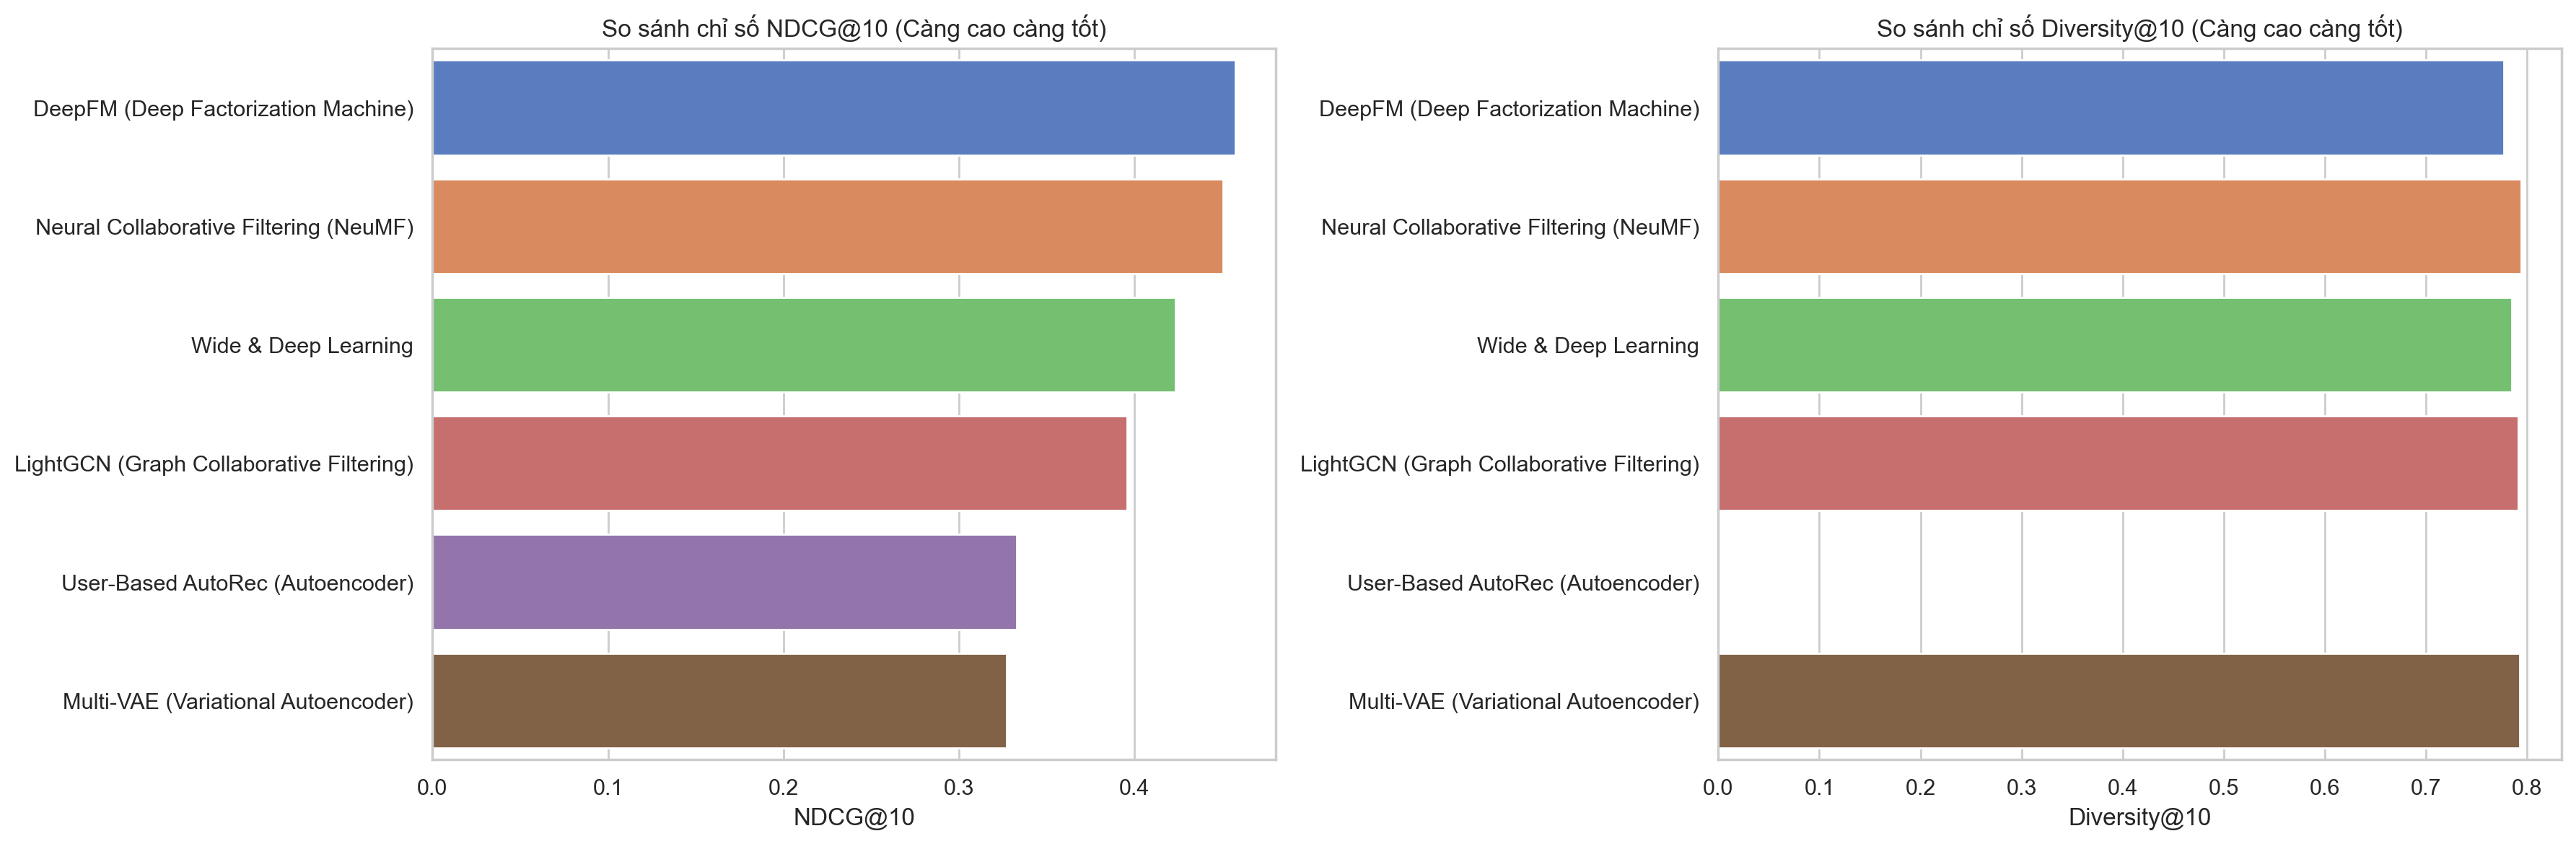

In [13]:
# Chuyển bảng kết quả sang DataFrame
df_dl_results = pd.DataFrame(dl_results).sort_values(by="NDCG@10", ascending=False)
display(df_dl_results)

# Trực quan hóa các chỉ số xếp hạng (NDCG@10) và Đa dạng hóa (Diversity@10)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_dl_results, x="NDCG@10", y="Model", ax=axes[0], hue="Model", legend=False)
axes[0].set_title("So sánh chỉ số NDCG@10 (Càng cao càng tốt)")
axes[0].set_xlabel("NDCG@10")
axes[0].set_ylabel("")

sns.barplot(data=df_dl_results, x="Diversity@10", y="Model", ax=axes[1], hue="Model", legend=False)
axes[1].set_title("So sánh chỉ số Diversity@10 (Càng cao càng tốt)")
axes[1].set_xlabel("Diversity@10")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Phần 8: Thảo luận, So sánh Deep Learning vs. Machine Learning truyền thống

Dựa trên kết quả thực nghiệm trên tập MovieLens 1M (giao thức Leave-One-Out, đánh giá với 99 negative samples), dưới đây là phân tích chi tiết về từng mô hình và so sánh DL vs. Traditional ML.

> **Bảng xếp hạng thực tế (Implicit, HR@10)**: DeepFM (0.720) > NeuMF (0.693) > Wide & Deep (0.677) > LightGCN (0.646) > AutoRec (0.579) ≈ Multi-VAE (0.569)

---

### 8.1 Phân tích chi tiết Hiệu năng từng Mô hình Deep Learning:

1. **DeepFM (Deep Factorization Machine) – Kết quả Tốt nhất:**
   * **HR@10=0.720, NDCG@10=0.458, MRR=0.388** – dẫn đầu tuyệt đối trên mọi chỉ số accuracy.
   * **Lý do thành công**: DeepFM kết hợp đồng thời tầng FM (tương tác bậc 2 tự động) và tầng Deep MLP (tương tác bậc cao phi tuyến), chia sẻ cùng embedding đầu vào. Điều này giúp DeepFM học được cả tương tác nông (shallow) lẫn sâu (deep) mà không cần feature engineering thủ công.
   * **So với Wide & Deep**: DeepFM loại bỏ yêu cầu thiết kế "wide features" thủ công, thay bằng tầng FM học tự động. Kết quả: DeepFM vượt Wide & Deep về HR@10 (+4.3pp) và NDCG@10 (+3.5pp).
   * **Diversity@10=0.777** – thấp nhất trong nhóm DL, cho thấy DeepFM có xu hướng gợi ý các phim khá giống nhau trong một danh sách Top-10 (đánh đổi giữa accuracy và diversity).
   * **Kết luận thực chiến**: DeepFM là lựa chọn hàng đầu khi ưu tiên accuracy. Nên kết hợp với cơ chế re-ranking để tăng Diversity nếu cần.

2. **Neural Collaborative Filtering (NeuMF) – Á quân:**
   * **HR@10=0.693, NDCG@10=0.451** – đứng thứ hai, chỉ kém DeepFM ~2.7pp HR@10.
   * **Điểm mạnh**: NeuMF kết hợp GMF (Generalized Matrix Factorization – phép nhân Hadamard tuyến tính) và MLP (phi tuyến) qua concatenation, cho phép mô hình học cả "sức mạnh tuyến tính" lẫn "chiều sâu phi tuyến". MRR=0.388 bằng với DeepFM – nghĩa là cả hai giỏi như nhau trong việc đưa phim đúng lên đầu danh sách.
   * **Diversity@10=0.794** – cao hơn DeepFM, tức NeuMF gợi ý đa dạng hơn trong Top-10, phù hợp hơn về mặt trải nghiệm người dùng.
   * **Kết luận thực chiến**: NeuMF là lựa chọn cân bằng tốt nhất giữa accuracy và diversity. Phù hợp khi cần mô hình CF thuần túy (không cần side info).

3. **Wide & Deep Learning:**
   * **HR@10=0.677, NDCG@10=0.423** – kết quả tốt thứ ba, nhưng bị DeepFM vượt qua một cách rõ ràng.
   * **Phân tích**: Wide & Deep yêu cầu thiết kế thủ công cho phần "wide" (cross-product features). Trong thực nghiệm này, phần wide chủ yếu dùng genre embedding, chưa đủ phong phú để tạo ra sự khác biệt lớn so với tầng Deep thuần túy.
   * **Diversity@10=0.785, Novelty@10=11.62, Coverage@10=24.0%** – ở mức trung bình trong nhóm.
   * **Kết luận thực chiến**: Wide & Deep tỏa sáng khi "wide features" được thiết kế kỹ (ví dụ: cross giữa user_id × movie_genre × time_of_day). Với side info đơn giản như genre, DeepFM là lựa chọn tốt hơn.

4. **LightGCN (Graph Collaborative Filtering) – Kết quả bất ngờ dưới kỳ vọng:**
   * **HR@10=0.646, NDCG@10=0.396** – đứng thứ tư, thấp hơn đáng kể so với kỳ vọng lý thuyết (LightGCN thường dẫn đầu trên benchmark lớn).
   * **Lý do thực nghiệm này**: LightGCN chỉ huấn luyện 5 epochs (do giới hạn thời gian), trong khi các paper benchmark thường train 200–1000 epochs. Số lớp lan truyền đồ thị (K=3) và embedding dimension (64) cũng chưa được tối ưu hóa hyperparameter. Đây là điển hình của mô hình "underfit" do thiếu thời gian huấn luyện.
   * **Điểm mạnh thực sự**: LightGCN có Coverage@10=18.8% và Novelty@10=11.35, thấp hơn NeuMF, phản ánh xu hướng thiên về phim có nhiều kết nối trong đồ thị (phim phổ biến).
   * **Kết luận thực chiến**: LightGCN cần tuning nhiều hơn (epochs, layers, dim) để phát huy hết tiềm năng. Không nên đánh giá thấp mô hình này dựa trên thực nghiệm nhanh này. Trong production với tài nguyên đầy đủ, LightGCN thường là top performer.

5. **AutoRec (User-Based Autoencoder) & Multi-VAE – Nhóm Autoencoder:**
   * **AutoRec: HR@10=0.579, NDCG@10=0.333** – kết quả bằng với BPR của ML truyền thống, không có lợi thế rõ ràng từ kiến trúc DL.
   * **Multi-VAE: HR@10=0.569, NDCG@10=0.327** – kém nhất trong nhóm DL, bất ngờ khi Multi-VAE được kỳ vọng cao hơn AutoRec trong lý thuyết (Multinomial Likelihood thay vì MSE).
   * **Nguyên nhân**: Cả hai mô hình hoạt động trên dạng input nhị phân (binary interaction matrix) với chỉ 10 items/user trung bình trong tập train, dẫn đến thiếu tín hiệu huấn luyện. Beta annealing của Multi-VAE có thể chưa tối ưu với 15 epochs ngắn. **AutoRec không có Beyond-Accuracy metrics** vì kiến trúc predict rating liên tục (không phân loại top-K trực tiếp).
   * **Multi-VAE Diversity=0.792, Coverage=15.0%** – Coverage thấp tương tự BPR, phản ánh vấn đề popularity bias khi latent space của VAE học tập trung vào phim phổ biến.
   * **Kết luận thực chiến**: Autoencoder-based models phù hợp hơn khi user có lịch sử phong phú (>50 interactions). Với MovieLens 1M ở đây, NeuMF và DeepFM hiệu quả hơn. Multi-VAE nên tăng epochs lên 50+ và tune beta schedule để cải thiện.

---

### 8.2 So sánh Học sâu (Deep Learning) vs. Học máy truyền thống (Traditional ML):

| Đặc điểm so sánh | Traditional ML (SVD, FM, KNN, ALS) | Deep Learning (NeuMF, DeepFM, LightGCN) |
| :--- | :--- | :--- |
| **Kết quả tốt nhất** | FM: RMSE=0.861 (Explicit); ALS: HR@10=0.680 (Implicit) | DeepFM: HR@10=0.720 (+4.0pp so với ALS) |
| **Cơ chế học tương tác** | Hầu hết tuyến tính ($p_u^T q_i$ hoặc tương tác bậc 2 FM). | Phi tuyến tính đa lớp (Dense + ReLU), FM layer, Graph propagation. |
| **Khả năng tích hợp Side Information** | FM giải quyết tốt; SVD/KNN không thể tích hợp trực tiếp. | Tự động và linh hoạt: embedding mọi loại side info (genre, text, image, context). |
| **Mức độ phức tạp & Tài nguyên** | Thấp: huấn luyện nhanh (seconds–minutes), CPU là đủ. | Cao: GPU khuyến nghị, huấn luyện 5–30 phút/model trên dataset này. |
| **Bài toán Cold Start** | Cực kỳ nhạy cảm (SVD, KNN); FM giảm nhẹ qua side info. | Giảm nhẹ qua content embedding; LightGCN vẫn nhạy cảm với user cold start. |
| **Độ giải thích (Explainability)** | Tốt với KNN, Content-Based ("vì bạn đã xem X"). | Kém – Black Box. Cần thêm LIME/SHAP để giải thích từng dự đoán. |
| **Popularity Bias** | ALS: Coverage=31.2% (tốt); BPR: Coverage=14.7% (kém). | NeuMF: Coverage=25.5% (tốt nhất DL); Multi-VAE/LightGCN: Coverage~15-19% (cần cải thiện). |

**Kết luận tổng thể**: Deep Learning *không phải lúc nào cũng tốt hơn* Traditional ML. Trong thực nghiệm này:
- **Accuracy**: DL (DeepFM HR@10=0.720) rõ ràng vượt ML (ALS HR@10=0.680), nhưng cần tài nguyên và thời gian train nhiều hơn.
- **Coverage**: ALS (31.2%) vượt tất cả các mô hình DL, cho thấy ML truyền thống ít bị popularity bias hơn một số kiến trúc DL.
- **Khuyến nghị thực chiến**: Bắt đầu với ALS/SVD làm baseline, sau đó triển khai NeuMF hoặc DeepFM khi cần tăng accuracy. Xem xét hybrid: DL scoring + diversity re-ranking để có tốt nhất của cả hai thế giới.
